In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kruskal, mannwhitneyu

([Swap(1), Reversion(1), Insertion(1), Slide(1)])

([Swap(2), Reversion(2), Insertion(2), Slide(2)])

([Swap(3), Reversion(3), Insertion(3), Slide(3)])

([Swap(4), Reversion(4), Insertion(4), Slide(4)])

In [3]:
def plot_boxplots(filename, title):
    data = np.load(filename)
    outer_array = data[data.files[0]] 

    plt.figure()
    plt.title(f"{title}")
    plt.boxplot(outer_array.T, notch=True)
    plt.xlabel("Array Index")
    plt.ylabel("Values")
    plt.show()

In [4]:
# Deterministic
filename = 'FX_values_2_0.npz'
data = np.load(filename)
data = data["FX_values_"]
a0 = data[0, :]
b0 = data[1, :]
c0 = data[2, :]
d0 = data[3, :]

# Stochastic
filename = 'FX_values_2_1.npz'
data = np.load(filename)
data = data["FX_values_"]
a1 = data[0, :]
b1 = data[1, :]
c1 = data[2, :]
d1 = data[3, :]

## Deterministic

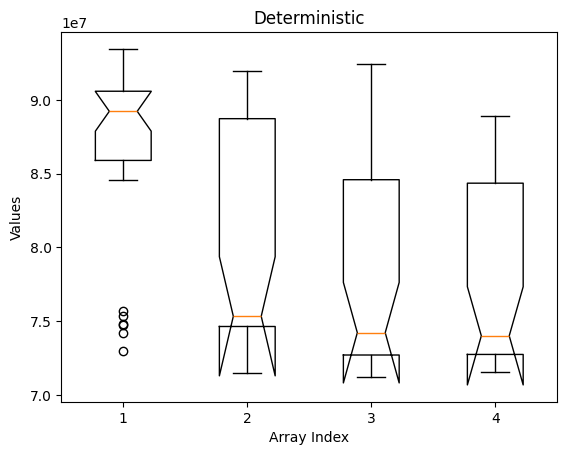

In [5]:
filename = 'FX_values_2_0.npz'
plot_boxplots(filename, "Deterministic")

In [6]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a0))
print(shapiro(b0))
print(shapiro(c0))
print(shapiro(d0))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.7497811326596875, pvalue=9.032637757457492e-06)
ShapiroResult(statistic=0.7914144474647605, pvalue=4.590873269452781e-05)
ShapiroResult(statistic=0.7367230091975108, pvalue=5.596592591611018e-06)
ShapiroResult(statistic=0.7005618777359308, pvalue=1.589862609807324e-06)


In [7]:
# H0: the medians of the groups are equal

print(kruskal(a0, b0, c0, d0))

# since H0 is rejected, the medians are not equal.

KruskalResult(statistic=29.93123966942153, pvalue=1.4267904897151397e-06)


In [15]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, b0, alternative='two-sided')}")
print(f"a vs c: {mannwhitneyu(a0, c0, alternative='two-sided')}")
print(f"a vs d: {mannwhitneyu(a0, d0, alternative='two-sided')}")
print(f"b vs c: {mannwhitneyu(b0, c0, alternative='two-sided')}")
print(f"b vs d: {mannwhitneyu(b0, d0, alternative='two-sided')}")
print(f"c vs d: {mannwhitneyu(c0, d0, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=650.0, pvalue=0.0031829591616507357)
a vs c: MannwhitneyuResult(statistic=728.0, pvalue=4.0839534518280284e-05)
a vs d: MannwhitneyuResult(statistic=784.0, pvalue=8.197497229004642e-07)
b vs c: MannwhitneyuResult(statistic=565.0, pvalue=0.090490360906144)
b vs d: MannwhitneyuResult(statistic=621.0, pvalue=0.011710683792873126)
c vs d: MannwhitneyuResult(statistic=485.0, pvalue=0.6100075520376812)


There is no significant difference between any pairs of groups (a, b, c, d)

## Stochastic

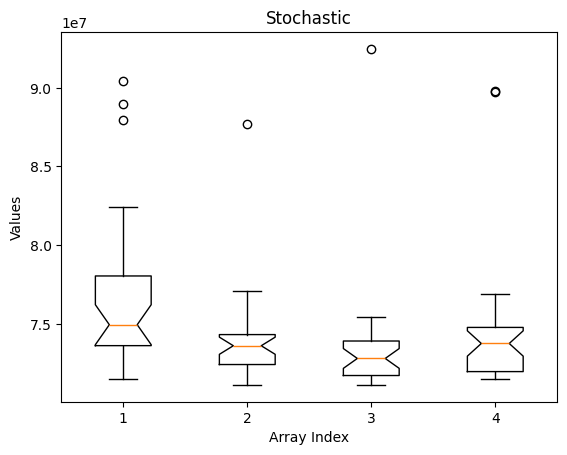

In [9]:
filename = 'FX_values_2_1.npz'
plot_boxplots(filename, "Stochastic")

In [10]:
# H0: there is no difference between your distribution and a normal distribution

print(shapiro(a1))
print(shapiro(b1))
print(shapiro(c1))
print(shapiro(d1))

# Based on the results, none of them are normally distributed.

ShapiroResult(statistic=0.7828365635177983, pvalue=3.240361100834626e-05)
ShapiroResult(statistic=0.6130381462711008, pvalue=1.0568192839913972e-07)
ShapiroResult(statistic=0.47417151594949436, pvalue=2.8879970722433683e-09)
ShapiroResult(statistic=0.5887835935974706, pvalue=5.33993925220467e-08)


In [11]:
# H0: the medians of the groups are equal

print(kruskal(a1, b1, c1, d1))

# since H0 is rejected, so the medians are not equal.

KruskalResult(statistic=16.21261707988981, pvalue=0.0010256554555193773)


In [12]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a1, b1, alternative='two-sided')}")
print(f"a vs c: {mannwhitneyu(a1, c1, alternative='two-sided')}")
print(f"a vs d: {mannwhitneyu(a1, d1, alternative='two-sided')}")
print(f"b vs c: {mannwhitneyu(b1, c1, alternative='two-sided')}")
print(f"b vs d: {mannwhitneyu(b1, d1, alternative='two-sided')}")
print(f"c vs d: {mannwhitneyu(c1, d1, alternative='two-sided')}")

a vs b: MannwhitneyuResult(statistic=649.0, pvalue=0.003338612259442543)
a vs c: MannwhitneyuResult(statistic=703.0, pvalue=0.00018916193602108462)
a vs d: MannwhitneyuResult(statistic=623.0, pvalue=0.010762612595411515)
b vs c: MannwhitneyuResult(statistic=537.0, pvalue=0.20094889697592833)
b vs d: MannwhitneyuResult(statistic=444.0, pvalue=0.9351919702393391)
c vs d: MannwhitneyuResult(statistic=370.0, pvalue=0.23984999119107964)


There is no significant difference between any pairs of groups (a, b, c, d)

# Deterministic x Stochastic

In [13]:
# H0: the medians of the groups are equal

print(kruskal(a0, a1))
print(kruskal(b0, b1))
print(kruskal(c0, c1))
print(kruskal(d0, d1))

KruskalResult(statistic=23.229726775956294, pvalue=1.4375790829896512e-06)
KruskalResult(statistic=16.17136612021858, pvalue=5.786218181611498e-05)
KruskalResult(statistic=5.736393442622983, pvalue=0.016616878967820384)
KruskalResult(statistic=1.295956284152993, pvalue=0.2549531779982523)


The medians of groups a0 and a1, b0 and b1, and c0 and c1 are significantly different.

There is no significant difference in the medians of groups d0 and d1.

In [14]:
# H0: the distribution underlying the two samples is the same

print(f"a vs b: {mannwhitneyu(a0, a1, alternative='less')}")
print(f"a vs c: {mannwhitneyu(b0, b1, alternative='less')}")
print(f"a vs d: {mannwhitneyu(c0, c1, alternative='less')}")

a vs b: MannwhitneyuResult(statistic=776.0, pvalue=0.9999993073739609)
a vs c: MannwhitneyuResult(statistic=722.0, pvalue=0.9999719636019341)
a vs d: MannwhitneyuResult(statistic=612.0, pvalue=0.9918575955259413)


There is no significant difference between any pairs of groups (a, b, c)